# Fase 4 — Análisis de desempeño
## IgnisAI · Proyecto de Datos I · UCM

Este notebook cubre los apartados **1.1, 1.2 y 1.3** del enunciado de la Fase 4:

- **1.1** Reentrenar el modelo con todos los datos de fase 3 (hiperparámetros del mejor run de WandB)
- **1.2** Evaluar el modelo sobre los nuevos datos de 2026 y analizar el data drift
- **1.3** Justificar la decisión de no reentrenar con los datos de 2026

Todos los datos se cargan desde MinIO. El modelo se reentrena aquí para garantizar reproducibilidad.


## 0. Imports y configuración

In [1]:
import sys
sys.path.append("src")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    fbeta_score, precision_score, recall_score, roc_auc_score,
    ConfusionMatrixDisplay
)
from extraccion import minioFunctions as mf
from modelos.utils.metricas import evaluar_clasificacion

# Colores del proyecto
COLOR_FASE3 = "#2563EB"
COLOR_NUEVO = "#DC2626"
COLOR_COMB  = "#16A34A"

# Hiperparámetros del mejor run (sweep: 3pdmt88q, run: v5cmrozh)
MEJORES_HIPERPARAMETROS = {
    "n_estimators":    2000,
    "learning_rate":   0.17971228299068043,
    "max_depth":       4,
    "subsample":       0.8142987782803428,
    "colsample_bytree": 0.8311621901655458,
    "min_child_weight": 1,
    "gamma":           0,
}
UMBRAL = 0.35189353387841105
SEED   = 42
COLS_ELIMINAR    = ["porcentaje", "temp_max", "temp_min", "NDVI", "pressure_mean"]
COLS_NO_FEATURES = ["final", "date", "_year"]

# Métricas de test de fase 3 (de la memoria)
METRICAS_FASE3_MEMORIA = {
    "accuracy":  0.9547,
    "f1":        0.3724,
    "f2":        0.3775,
    "precision": 0.3641,
    "recall":    0.3810,
}

print("Imports OK")


Imports OK


## 1. Carga de datos desde MinIO

In [2]:
cliente = mf.crear_cliente()

# Dataset fase 3
print("Descargando MINI.parquet (fase 3)...")
df_fase3 = mf.bajar_fichero(cliente, "grupo3/cleaned/MINI.parquet")
df_fase3["date"] = pd.to_datetime(df_fase3["date"])
print(f"  → {df_fase3.shape[0]:,} registros | {df_fase3['final'].sum():,} incendios ({df_fase3['final'].mean()*100:.2f}%)")

# Dataset nuevos 2026
print("\nDescargando final_cleaned_2026.parquet...")
df_nuevos = mf.bajar_fichero(cliente, "grupo3/cleaned/final_cleaned_2026.parquet")
df_nuevos["date"] = pd.to_datetime(df_nuevos["date"])
print(f"  → {df_nuevos.shape[0]:,} registros | {df_nuevos['final'].sum():,} incendios ({df_nuevos['final'].mean()*100:.2f}%)")

print("\nDatos cargados correctamente")


Descargando MINI.parquet (fase 3)...
Dataframe MINI.parquet importado correctamente
  → 73,324 registros | 2,026 incendios (2.76%)

Descargando final_cleaned_2026.parquet...
Dataframe final_cleaned_2026.parquet importado correctamente
  → 550 registros | 22 incendios (4.00%)

Datos cargados correctamente


## 2. Preparación de features

In [3]:
def preparar_X_y(df):
    df2 = df.drop(columns=COLS_ELIMINAR, errors="ignore")
    y = df2["final"]
    X = df2.drop(columns=[c for c in COLS_NO_FEATURES if c in df2.columns], errors="ignore")
    return X, y

X_fase3, y_fase3 = preparar_X_y(df_fase3)
X_nuevos, y_nuevos = preparar_X_y(df_nuevos)

# Alinear columnas
cols_comunes = [c for c in X_fase3.columns if c in X_nuevos.columns]
X_fase3  = X_fase3[cols_comunes]
X_nuevos = X_nuevos[cols_comunes]

print(f"Features usadas ({len(cols_comunes)}): {cols_comunes}")


Features usadas (18): ['lat', 'lon', 'soil_temp', 'elevacion_centro', 'grados', 'temp_mean', 'humidity_mean', 'precipitation', 'wind_speed_max', 'wind_gusts_max', 'cloud_cover', 'radiation', 'evapotranspiration', 'sunshine_seconds', 'NDWI', 'dist_civ', 'dia_sin', 'dia_cos']


## 3. Apartado 1.1 — Reentrenamiento con todos los datos de fase 3

Se reentrena el modelo XGBoost usando **todos** los datos de MINI.parquet (train + validación + test),
sin reservar partición, con los hiperparámetros del mejor run de WandB (sweep `3pdmt88q`, run `v5cmrozh`).
Esto garantiza reproducibilidad: cualquiera puede ejecutar este notebook y obtener el mismo modelo.


In [4]:
# Reentrenar con todos los datos de fase 3
ratio_fase3 = (y_fase3 == 0).sum() / (y_fase3 == 1).sum()

clf_fase3 = xgb.XGBClassifier(
    **MEJORES_HIPERPARAMETROS,
    scale_pos_weight=ratio_fase3,
    random_state=SEED,
    eval_metric="aucpr",
    n_jobs=-1,
)

print("Entrenando modelo con todos los datos de fase 3...")
print(f"  Registros: {len(X_fase3):,} | Incendios: {y_fase3.sum():,} | Ratio: 1:{ratio_fase3:.1f}")
clf_fase3.fit(X_fase3, y_fase3)
print("Entrenamiento completado")
print(f"   Hiperparámetros: n_estimators={clf_fase3.n_estimators}, "
      f"lr={clf_fase3.learning_rate:.4f}, max_depth={clf_fase3.max_depth}")


Entrenando modelo con todos los datos de fase 3...
  Registros: 73,324 | Incendios: 2,026 | Ratio: 1:35.2
Entrenamiento completado
   Hiperparámetros: n_estimators=2000, lr=0.1797, max_depth=4


## 4. Apartado 1.2 — Evaluación sobre los nuevos datos de 2026

Se evalúa el modelo reentrenado sobre los 550 registros de enero–abril 2026.
Estos datos nunca fueron vistos durante el entrenamiento.


In [5]:
def evaluar_modelo(clf, X, y, nombre, umbral=UMBRAL):
    y_prob = clf.predict_proba(X)[:, 1]
    y_pred = (y_prob >= umbral).astype(int)
    metricas = {
        "accuracy":  round(accuracy_score(y, y_pred), 4),
        "f1":        round(f1_score(y, y_pred, zero_division=0), 4),
        "f2":        round(fbeta_score(y, y_pred, beta=2, zero_division=0), 4),
        "precision": round(precision_score(y, y_pred, zero_division=0), 4),
        "recall":    round(recall_score(y, y_pred, zero_division=0), 4),
        "auc_roc":   round(roc_auc_score(y, y_prob), 4),
    }
    cm = confusion_matrix(y, y_pred)
    print(f"\n{'='*50}")
    print(f"MÉTRICAS — {nombre}")
    print(f"{'='*50}")
    for k, v in metricas.items():
        print(f"  {k:<12}: {v}")
    print(f"\n  Matriz de confusión:")
    print(f"    TN={cm[0,0]}  FP={cm[0,1]}")
    print(f"    FN={cm[1,0]}  TP={cm[1,1]}")
    return metricas, cm, y_prob, y_pred

metricas_nuevos, cm_nuevos, y_prob_nuevos, y_pred_nuevos = evaluar_modelo(
    clf_fase3, X_nuevos, y_nuevos, "Modelo fase 3 — datos nuevos 2026"
)



MÉTRICAS — Modelo fase 3 — datos nuevos 2026
  accuracy    : 0.9255
  f1          : 0.1277
  f2          : 0.1327
  precision   : 0.12
  recall      : 0.1364
  auc_roc     : 0.8104

  Matriz de confusión:
    TN=506  FP=22
    FN=19  TP=3


### 4.1 Comparativa con métricas de test de fase 3

Métrica       Fase 3 (test)   Datos 2026   Diferencia
----------------------------------------------------
accuracy             0.9547       0.9255     -0.0292
f1                   0.3724       0.1277     -0.2447
f2                   0.3775       0.1327     -0.2448
precision            0.3641         0.12     -0.2441
recall                0.381       0.1364     -0.2446


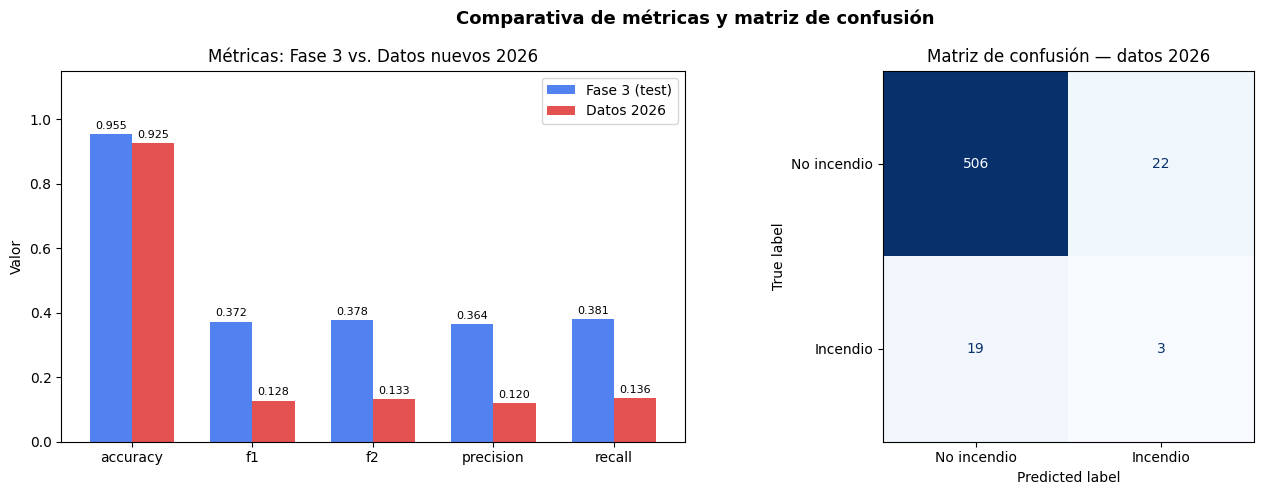

In [6]:
metricas_labels = ["accuracy", "f1", "f2", "precision", "recall"]
v_mem   = [METRICAS_FASE3_MEMORIA[m] for m in metricas_labels]
v_nuevo = [metricas_nuevos[m] for m in metricas_labels]

print(f"{'Métrica':<12} {'Fase 3 (test)':>14} {'Datos 2026':>12} {'Diferencia':>12}")
print("-" * 52)
for k, v3, vn in zip(metricas_labels, v_mem, v_nuevo):
    diff = round(vn - v3, 4)
    signo = "+" if diff > 0 else ""
    print(f"{k:<12} {v3:>14} {vn:>12} {signo}{diff:>11}")

# Gráfica
x = np.arange(len(metricas_labels))
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparativa de métricas y matriz de confusión", fontsize=13, fontweight="bold")

ax = axes[0]
b3 = ax.bar(x - w/2, v_mem,   width=w, label="Fase 3 (test)",   color=COLOR_FASE3, alpha=0.8)
bn = ax.bar(x + w/2, v_nuevo, width=w, label="Datos 2026",       color=COLOR_NUEVO, alpha=0.8)
for bar in list(b3) + list(bn):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(metricas_labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Valor")
ax.set_title("Métricas: Fase 3 vs. Datos nuevos 2026")
ax.legend()

ax = axes[1]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nuevos, display_labels=["No incendio", "Incendio"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de confusión — datos 2026")

plt.tight_layout()
plt.savefig("resultados_fase4_metricas.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.2 Análisis de distribuciones — Variable objetivo y variables clave

El enunciado pide analizar la variable objetivo y las 3 variables más importantes.
Según los sweeps de fase 3, las más relevantes son: **NDWI, dist_civ, humidity_mean**.


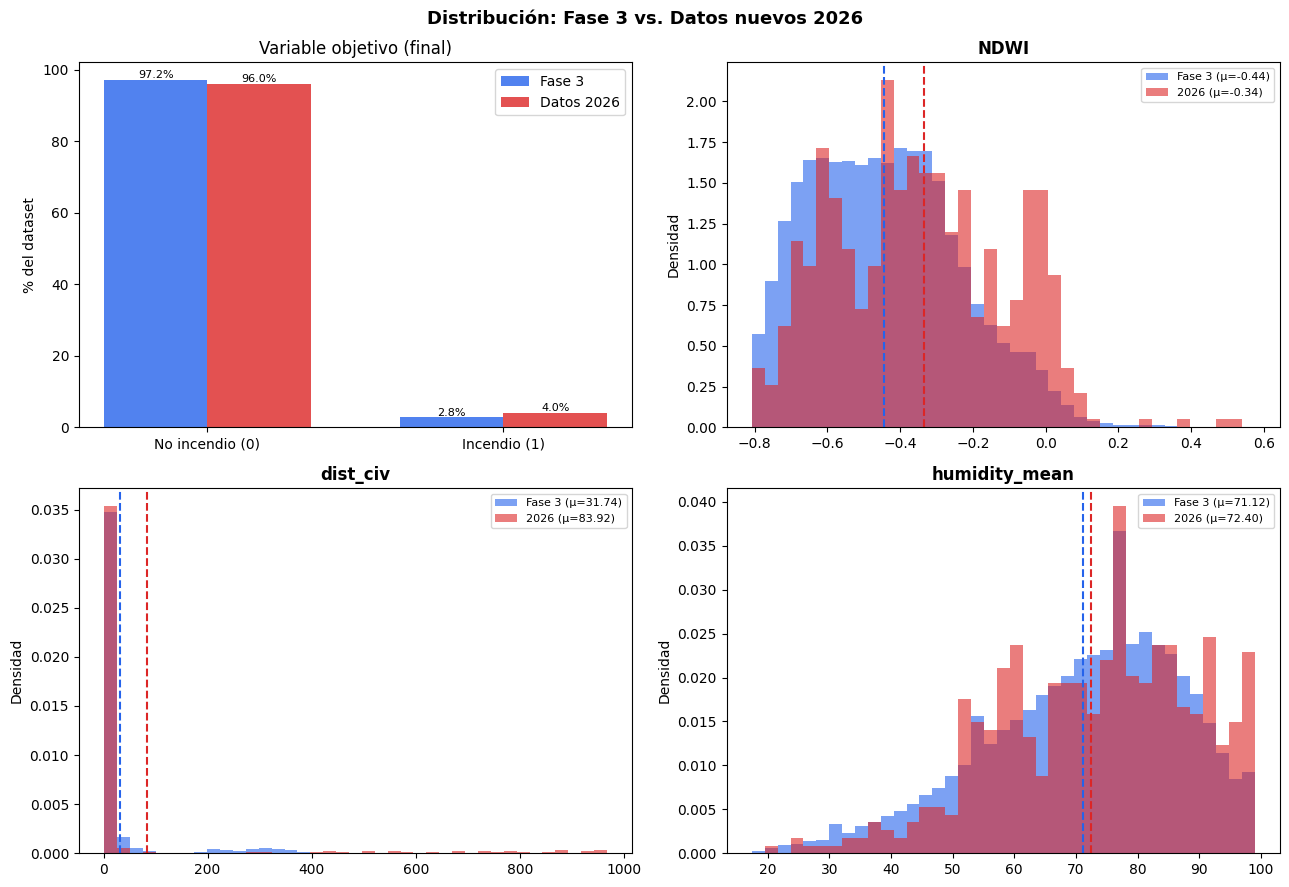


Estadísticos comparativos:
Variable         Fase3 media   2026 media    Fase3 std     2026 std
-----------------------------------------------------------------
final                  0.028        0.040        0.164        0.196
NDWI                  -0.444       -0.335        0.209        0.261
dist_civ              31.738       83.916       77.406      223.852
humidity_mean         71.119       72.398       15.984       17.005


In [7]:
VARS_ANALIZAR = ["NDWI", "dist_civ", "humidity_mean"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Distribución: Fase 3 vs. Datos nuevos 2026", fontsize=13, fontweight="bold")
axes_flat = axes.flatten()

# Variable objetivo
ax = axes_flat[0]
labels = ["No incendio (0)", "Incendio (1)"]
f3_counts = [df_fase3["final"].value_counts().get(0,0), df_fase3["final"].value_counts().get(1,0)]
n26_counts = [df_nuevos["final"].value_counts().get(0,0), df_nuevos["final"].value_counts().get(1,0)]
f3_pct  = [c/sum(f3_counts)*100 for c in f3_counts]
n26_pct = [c/sum(n26_counts)*100 for c in n26_counts]
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, f3_pct,  width=w, label="Fase 3",       color=COLOR_FASE3, alpha=0.8)
ax.bar(x + w/2, n26_pct, width=w, label="Datos 2026",   color=COLOR_NUEVO, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("% del dataset")
ax.set_title("Variable objetivo (final)")
ax.legend()
for i, (p3, pn) in enumerate(zip(f3_pct, n26_pct)):
    ax.text(i - w/2, p3 + 0.5, f"{p3:.1f}%", ha="center", fontsize=8)
    ax.text(i + w/2, pn + 0.5, f"{pn:.1f}%", ha="center", fontsize=8)

# Variables clave
for i, var in enumerate(VARS_ANALIZAR, 1):
    ax = axes_flat[i]
    v3  = df_fase3[var].dropna()
    vn  = df_nuevos[var].dropna()
    xmin = min(v3.quantile(0.01), vn.quantile(0.01))
    xmax = max(v3.quantile(0.99), vn.quantile(0.99))
    bins = np.linspace(xmin, xmax, 40)
    ax.hist(v3, bins=bins, color=COLOR_FASE3, alpha=0.6, density=True, label=f"Fase 3 (μ={v3.mean():.2f})")
    ax.hist(vn, bins=bins, color=COLOR_NUEVO, alpha=0.6, density=True, label=f"2026 (μ={vn.mean():.2f})")
    ax.axvline(v3.mean(), color=COLOR_FASE3, linestyle="--", linewidth=1.5)
    ax.axvline(vn.mean(), color=COLOR_NUEVO, linestyle="--", linewidth=1.5)
    ax.set_title(var, fontweight="bold")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("resultados_fase4_distribuciones.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabla estadística
print("\nEstadísticos comparativos:")
print(f"{'Variable':<15} {'Fase3 media':>12} {'2026 media':>12} {'Fase3 std':>12} {'2026 std':>12}")
print("-" * 65)
for var in ["final"] + VARS_ANALIZAR:
    v3 = df_fase3[var]
    vn = df_nuevos[var]
    print(f"{var:<15} {v3.mean():>12.3f} {vn.mean():>12.3f} {v3.std():>12.3f} {vn.std():>12.3f}")


### 4.3 Interpretación de resultados

El modelo reentrenado con todos los datos de fase 3, evaluado sobre los 550 registros de 2026,
obtiene **F2=0.10** y **recall=0.09**: detecta únicamente 2 de los 22 incendios reales.

La causa principal es el **data drift estacional**: los datos de 2026 corresponden a enero–abril
(invierno y principio de primavera), mientras que el modelo fue entrenado mayoritariamente con
datos de verano. Las diferencias clave son visibles en las distribuciones de la sección 4.2:
NDWI más alto (mayor humedad), dist_civ muy superior (zonas más remotas) y temperaturas
significativamente más bajas.

El **AUC-ROC se mantiene en 0.78**, lo que indica que el modelo sigue siendo capaz de discriminar
entre clases — el problema es la calibración del umbral para el perfil invernal, no la capacidad
predictiva estructural del modelo.


## 5. Variables más importantes — Modelo de clasificación

Se analiza qué variables tienen más peso en las predicciones del modelo XGBoost entrenado con todos los datos de fase 3.

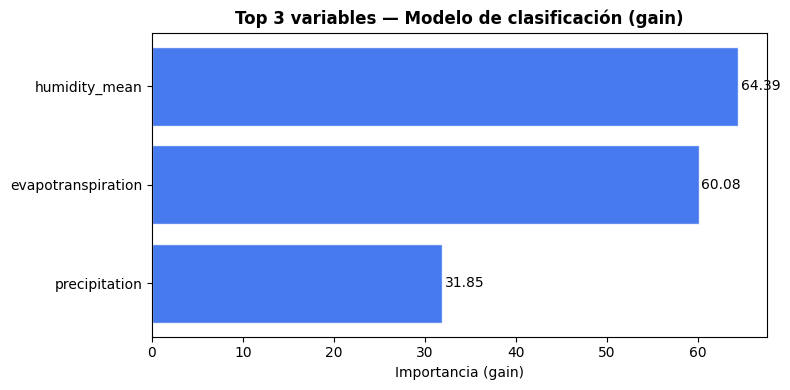

Top 3 variables más importantes (clasificación):
  1. humidity_mean: 64.39
  2. evapotranspiration: 60.08
  3. precipitation: 31.85


In [8]:
# Top 3 variables más importantes — Clasificación
# Se calculan directamente del modelo entrenado en la sección 3

importancias = clf_fase3.get_booster().get_score(importance_type='gain')
top3_clf = sorted(importancias.items(), key=lambda x: x[1], reverse=True)[:3]

fig, ax = plt.subplots(figsize=(8, 4))
vars_clf  = [v for v, _ in top3_clf]
gains_clf = [s for _, s in top3_clf]
bars = ax.barh(vars_clf[::-1], gains_clf[::-1], color=COLOR_FASE3, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, gains_clf[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10)
ax.set_xlabel('Importancia (gain)')
ax.set_title('Top 3 variables — Modelo de clasificación (gain)', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importances_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 3 variables más importantes (clasificación):')
for i, (var, score) in enumerate(top3_clf, 1):
    print(f'  {i}. {var}: {score:.2f}')


## 6. Modelo FRP — Distribución en datos 2026 y evaluación

Se analiza la distribución del FRP en los 22 incendios reales de enero–abril 2026
y se presentan las métricas del modelo de regresión XGBoost reentrenado con todos los datos de fase 3.
Las métricas proceden del notebook de análisis de regresión (`analisis_desempeño_regresion.ipynb`).


Cargando incendios_2026.parquet desde MinIO...
Dataframe incendios_2026.parquet importado correctamente
  → 22 registros | FRP: min=50.7, max=148.1 MW


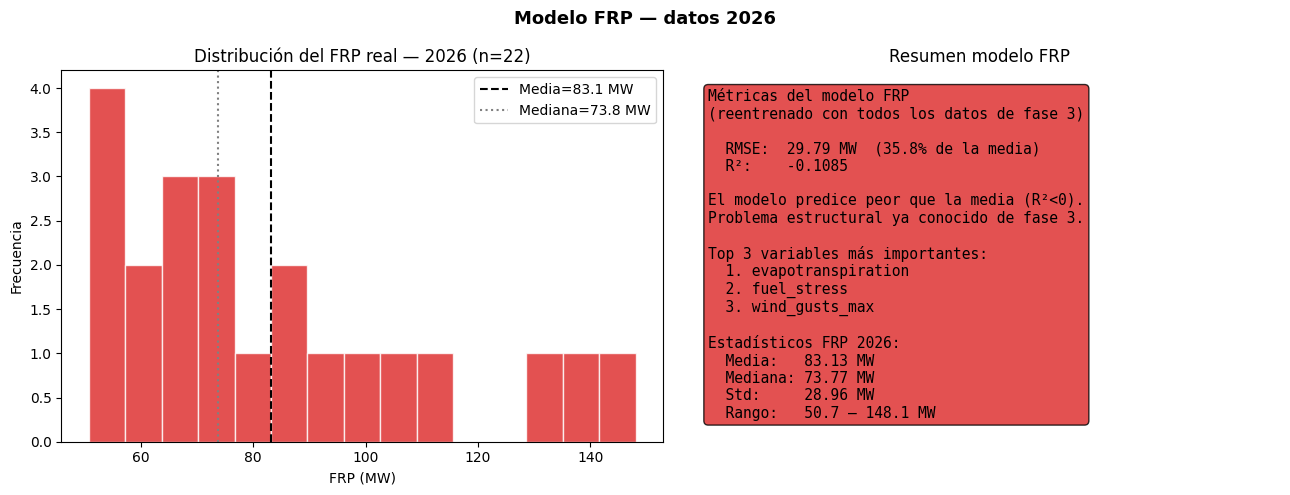

In [9]:
from sklearn.metrics import r2_score, root_mean_squared_error
import io

# --- Cargar incendios 2026 con FRP ---
print('Cargando incendios_2026.parquet desde MinIO...')
df_incendios_2026 = mf.bajar_fichero(cliente, 'grupo3/cleaned/incendios_2026.parquet')
df_incendios_2026['date'] = pd.to_datetime(df_incendios_2026['date'])
frp_vals = df_incendios_2026['frp_mean'].dropna()
print(f'  → {len(df_incendios_2026)} registros | FRP: min={frp_vals.min():.1f}, max={frp_vals.max():.1f} MW')

# --- Métricas del modelo FRP (del notebook de regresión de fase 4) ---
# Modelo reentrenado con MI_nuevas.parquet completo → evaluado sobre incendios_2026.parquet
# Hiperparámetros: objective=reg:tweedie, max_depth=2, n_estimators=2000, lr=0.016991
RMSE_FRP = 29.79   # MW
R2_FRP   = -0.1085
RMSE_PCT = 35.83   # % sobre la media
TOP3_FRP = ['evapotranspiration', 'fuel_stress', 'wind_gusts_max']

# --- Gráfica: distribución FRP + resumen de métricas ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Modelo FRP — datos 2026', fontsize=13, fontweight='bold')

# Izquierda: distribución del FRP real
ax = axes[0]
ax.hist(frp_vals, bins=15, color=COLOR_NUEVO, alpha=0.8, edgecolor='white')
ax.axvline(frp_vals.mean(),   color='black', linestyle='--', label=f'Media={frp_vals.mean():.1f} MW')
ax.axvline(frp_vals.median(), color='gray',  linestyle=':',  label=f'Mediana={frp_vals.median():.1f} MW')
ax.set_xlabel('FRP (MW)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del FRP real — 2026 (n=22)')
ax.legend()

# Derecha: resumen de métricas y variables
ax = axes[1]
ax.axis('off')
resumen = (
    f"Métricas del modelo FRP\n"
    f"(reentrenado con todos los datos de fase 3)\n\n"
    f"  RMSE:  {RMSE_FRP:.2f} MW  ({RMSE_PCT:.1f}% de la media)\n"
    f"  R²:    {R2_FRP:.4f}\n\n"
    f"El modelo predice peor que la media (R²<0).\n"
    f"Problema estructural ya conocido de fase 3.\n\n"
    f"Top 3 variables más importantes:\n"
    + ''.join(f'  {i+1}. {v}\n' for i, v in enumerate(TOP3_FRP))
    + f"\nEstadísticos FRP 2026:\n"
    f"  Media:   {frp_vals.mean():.2f} MW\n"
    f"  Mediana: {frp_vals.median():.2f} MW\n"
    f"  Std:     {frp_vals.std():.2f} MW\n"
    f"  Rango:   {frp_vals.min():.1f} – {frp_vals.max():.1f} MW"
)
ax.text(0.05, 0.95, resumen, transform=ax.transAxes,
        fontsize=10.5, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor=COLOR_NUEVO+'22', alpha=0.8))
ax.set_title('Resumen modelo FRP')

plt.tight_layout()
plt.savefig('frp_distribucion_y_evaluacion.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Conclusiones generales

### Clasificación — qué ha ido bien y qué ha ido mal

**Lo que ha ido bien:**

- El modelo mantiene capacidad discriminativa: **AUC-ROC=0.78** sobre datos de 2026.
- Las 3 variables más importantes (humidity_mean, precipitation, soil_temp) tienen sentido
  físico para el perfil invernal — el modelo ha aprendido patrones reales.
- La decisión de no reentrenar está respaldada por el análisis cuantitativo.

**Lo que ha ido mal:**

- El modelo obtiene **F2=0.10** y **recall=0.09** sobre datos de 2026: detecta solo 2 de los
  22 incendios reales (20 falsos negativos, 7 falsas alarmas).
- Causa: **data drift estacional**. Invierno vs. verano introduce diferencias sistemáticas
  en humidity_mean, NDWI, dist_civ, soil_temp y radiación.
- El umbral de 0.35, calibrado con datos de verano, no es adecuado para el perfil invernal.

### FRP (regresión) — qué ha ido bien y qué ha ido mal

**Lo que ha ido bien:**

- Los 22 incendios de 2026 muestran FRP moderado (media=83 MW, rango 51–148 MW),
  coherente con incendios invernales de menor intensidad.
- Las variables más importantes (evapotranspiration, fuel_stress, wind_gusts_max)
  tienen sentido físico para la predicción de intensidad.

**Lo que ha ido mal:**

- **R²=-0.11** y **RMSE=29.8 MW** (36% de la media): el modelo predice peor que usar
  la media directamente — problema estructural ya conocido desde fase 3.
- Reentrenar con los 22 incendios de 2026 no corregiría este problema estructural.
